# Example 007: Resonator parameter uncertainties

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import iddefix
from scipy.optimize import curve_fit
from functools import partial

### Modelling a three resonator impedance spectrum by three arbitrary resonators and some noise

In this example, will demonstrate how the resonator parameter uncertainties can be calculated and how they compare to the well known scipy.optimize.curve_fit function. 

Three random resonators ($R_s$, Q, $f_r$):

1. 400 $\Omega$, 30, 0.2 GHz
2. 1000 $\Omega$, 10, 1 GHz
3. 500 $\Omega$, 20, 1.75 GHz

And a Gaussian noise $\mathcal{N}(0,\sigma^2)$

In [2]:
# Assigning the resonator parameters

parameters = {
    "1": [400, 30, 0.2e9],
    "2": [1000, 10, 1e9],
    "3": [500, 20, 1.75e9],
}

# Computing the impedance spectrum for the resonators

frequency = np.linspace(0, 2e9, 1000)

noise = np.random.normal(0, 20, len(frequency))
impedance = iddefix.Impedances.n_Resonator_longitudinal_imp(frequency, parameters) + noise

#### Plotting the impedance spectrum

Plots of both the real- and imaginary part of the impedance, as well as the absolute of the complex impedance 

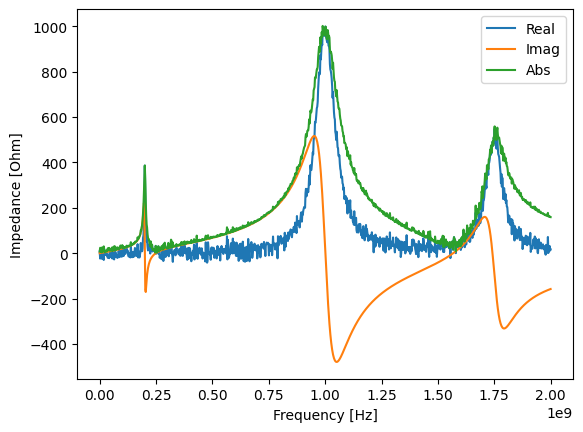

In [3]:
plt.plot(frequency, impedance.real, label="Real")
plt.plot(frequency, impedance.imag, label="Imag")
plt.plot(frequency, np.abs(impedance), label="Abs")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Impedance [Ohm]")
plt.legend()

### Fitting resonators with IDDEFIX on the absolute magnitude of the 3 resonator impdance spectrum

In [4]:
# Setting amount of resonators to fit

N_resonators = 3

# Bounds on resonators parameters
""" Bounds have this format [(Rs_min, Rs_max), (Q_min, Q_max), (fres_min, fres_max)].
ParameterBounds allows us to manually add a resonator with desired parameters """

parameterBounds = [
    (0, 2000),
    (1, 1e3),
    (0.1e9, 2e9),
    (0, 2000),
    (1, 1e3),
    (0.1e9, 2e9),
    (0, 2000),
    (1, 1e3),
    (0.1e9, 2e9),
]

#### Running IDDEFIX DE

In [5]:
%%time
DE_model = iddefix.EvolutionaryAlgorithm(
    frequency,
    impedance,
    N_resonators=N_resonators,
    parameterBounds=parameterBounds,
    plane="longitudinal",
    objectiveFunction=iddefix.ObjectiveFunctions.sumOfSquaredError,
)

DE_model.run_differential_evolution(
    maxiter=400, popsize=45, tol=0.01, mutation=(0.4, 1.0), crossover_rate=0.7
)
print(DE_model.warning)

[!] Using the fully decayed resonator formalism for impedance


Differential Evolution:  96%|███████████████████████████████████████████████████████████▋  | 385/400 [00:09<00:00, 42.19gen/s, conv=103.3 %]




----------------------------------------------------------------------
Resonator |   Rs [Ohm/m or Ohm]    |        Q         |    fres [Hz]     
----------------------------------------------------------------------
    1     |        9.97e+02        |       9.97       |    1.000e+09     
    2     |        3.99e+02        |      31.33       |    2.002e+08     
    3     |        4.98e+02        |      20.01       |    1.750e+09     
----------------------------------------------------------------------
callback function requested stop early
CPU times: user 5.93 s, sys: 1.19 s, total: 7.11 s
Wall time: 9.16 s


The found resonator parameters are close to being exactly correct. We can fit better by running for more generations or by doing the mimimization step:

#### Minimization step

In [6]:
DE_model.run_minimization_algorithm()

Method for minimization : Nelder-Mead


----------------------------------------------------------------------
Resonator |   Rs [Ohm/m or Ohm]    |        Q         |    fres [Hz]     
----------------------------------------------------------------------
    1     |        9.96e+02        |       9.97       |    1.000e+09     
    2     |        3.91e+02        |      30.24       |    2.001e+08     
    3     |        5.00e+02        |      20.05       |    1.750e+09     
----------------------------------------------------------------------


### Equivalent minimization step using scipy.optimize.curve_fit
We enforce the same constraints (parameters allowed to change by $\pm 10%$ and use the same bounds to ensure a comparable solution.

In [7]:
margin = [0.1] * 3
minimizationBounds = [
    sorted(((1 - margin[i % 3]) * p, (1 + margin[i % 3]) * p))
    for i, p in enumerate(DE_model.evolutionParameters)
]

def objective_function(x, *parameters):
    grouped_parameters = iddefix.utils.pars_to_dict(np.asarray(parameters))
    predicted_y = DE_model.fitFunction(x, grouped_parameters)
    return np.concatenate([predicted_y.real, predicted_y.imag])

popt, pcov = curve_fit(objective_function,
          frequency,
          np.concatenate([impedance.real, impedance.imag]),
          p0=DE_model.evolutionParameters,
          bounds=np.array(minimizationBounds).T,
          absolute_sigma=False
                      )

Both the minimization and the differential evolution routines return the parameters in a list size [3*Nres]

In [8]:
print("Minimization parameters:")
print(DE_model.minimizationParameters)
print("Curve_fit parameters:")
print(popt)

Minimization parameters:
[9.96059311e+02 9.97335506e+00 9.99952136e+08 3.90991072e+02
 3.02446749e+01 2.00072163e+08 4.99593151e+02 2.00519047e+01
 1.75010174e+09]
Curve_fit parameters:
[9.96059314e+02 9.97335514e+00 9.99952136e+08 3.90991146e+02
 3.02446907e+01 2.00072163e+08 4.99593154e+02 2.00519048e+01
 1.75010174e+09]


There's also a method to print them in Markdown syntax

### Assesing the fitting visually

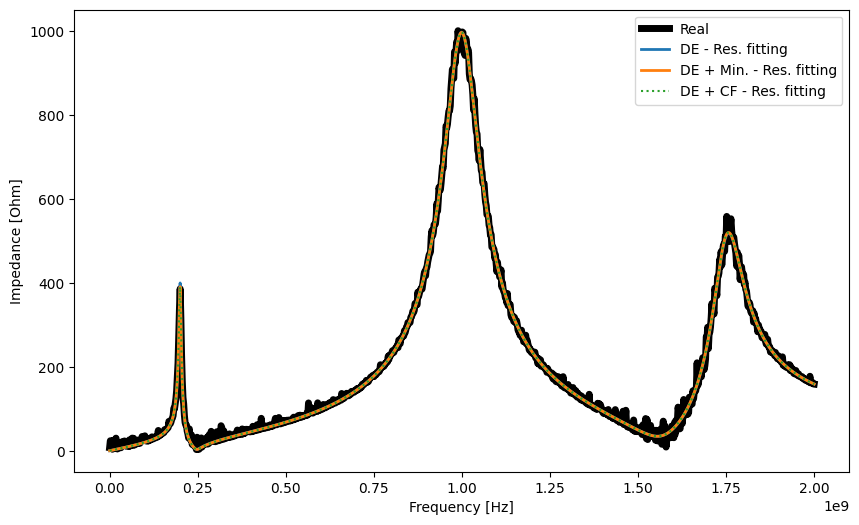

In [9]:
plt.figure(figsize=(10, 6))
result_DE = np.abs(DE_model.get_impedance(use_minimization=False))
result_DE_MIN = np.abs(DE_model.get_impedance())
result_DE_CF = np.abs(DE_model.fitFunction(DE_model.frequency_data, popt))

plt.plot(frequency, np.abs(impedance), lw=5, label="Real", color="black")
plt.plot(frequency, result_DE, lw=2, label="DE - Res. fitting")
plt.plot(frequency, result_DE_MIN, lw=2, label="DE + Min. - Res. fitting")
plt.plot(frequency, result_DE_CF, ':', label="DE + CF - Res. fitting")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Impedance [Ohm]")
plt.legend()

### Parameter uncertainties
The uncertainties are calculated the same way as in curve_fit. More precisely, the Jacobian of the system is calculated using the 3-point method and the covariance matrix is approximated as $(J^\top J)^{-1}$. The approximation corresponds to expressing the covariance matrix as the inverse of the Hessian. It is only valid close to the optimal solution and may yield unphysical values close to bounds.

The uncertainties are defined as the $1 \sigma$ standard deviation normalized by $(M - N) / \xi^2$, where $M$ is the number of frequencies considered, $N$ the number of parameters and $\xi^2$ the reduced chi-squared. It is equivalent to leaving the default option absolute_sigma=False in scipy.optimize.curve_fit().

The uncertainties can be estimated for both the Differential Evolution and minimization algorithms!

In [10]:
DE_model.evolutionParametersUncertainties

array([2.24511294e+00, 3.24459935e-02, 1.12880705e+05, 8.88666014e+00,
       9.88104041e-01, 7.10926820e+04, 2.40427963e+00, 1.42947522e-01,
       2.11208613e+05])

In [11]:
DE_model.minimizationParametersUncertainties

array([2.24211007e+00, 3.24199009e-02, 1.12799008e+05, 8.72241592e+00,
       9.55760720e-01, 7.37869745e+04, 2.40402980e+00, 1.42753179e-01,
       2.09960279e+05])

In [12]:
np.sqrt(np.diag(pcov)) # curve_fit standard deviations

array([2.24211009e+00, 3.24199019e-02, 1.12799007e+05, 8.72241826e+00,
       9.55761314e-01, 7.37869365e+04, 2.40402982e+00, 1.42753182e-01,
       2.09960271e+05])

A slight uncertainty reduction can be observed after running the minimization step which is the reason it is being used. Although it remains marginal in this example, the constrast is often starker. 

In [13]:
# Identical standard deviations between IDDEFIX and curve_fit
DE_model.minimizationParametersUncertainties / np.sqrt(np.diag(pcov))

array([0.99999999, 0.99999997, 1.00000001, 0.99999973, 0.99999938,
       1.00000052, 0.99999999, 0.99999998, 1.00000004])